In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from imblearn.over_sampling import SMOTE
import optuna
import matplotlib.pyplot as plt

In [4]:
# Load the dataset
df = pd.read_csv(r'C:\Users\khiew\Downloads\FYP Reduced Dataset.csv')

In [5]:
# Drop diseases with less than 1000 instances
disease_counts = df['diseases'].value_counts()
valid_diseases = disease_counts[disease_counts >= 500].index
df = df[df['diseases'].isin(valid_diseases)]

# Assuming that the target variable is 'diseases' and all other variables are input features
X = df.drop('diseases', axis=1)
y = df['diseases']

# Encode the target variable (diseases) if it's a categorical variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
num_classes = len(np.unique(y_train))
input_dim = X_train.shape[1]
print("Number of remaining classes in training set:", len(np.unique(y_train)))
print("Number of rows left:", len(df))

Number of remaining classes in training set: 201
Number of rows left: 168499


In [6]:
# Apply SMOTE for class balancing in the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Print the new class distribution after SMOTE
print("Class distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())
print("Number of remaining classes in training set:", len(np.unique(y_train_resampled)))
# Print the number of rows in the resampled training set
print("Number of rows in the resampled training set:", len(X_train_resampled))

Class distribution after SMOTE:
88     1002
150    1002
123    1002
125    1002
141    1002
       ... 
108    1002
39     1002
96     1002
192    1002
118    1002
Name: count, Length: 201, dtype: int64
Number of remaining classes in training set: 201
Number of rows in the resampled training set: 201402


In [7]:
# Optuna objective function
def objective(trial):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    # Suggest hyperparameters
    n_layers = trial.suggest_int('n_layers', 1, 3)
    for i in range(n_layers):
        num_units = trial.suggest_int(f'n_units_{i}', 64, 256, step=64)
        activation = trial.suggest_categorical(f'activation_{i}', ['relu', 'tanh'])
        model.add(layers.Dense(num_units, activation=activation))
        dropout_rate = trial.suggest_float(f'dropout_rate_{i}', 0.2, 0.5)
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(num_classes, activation='softmax'))

    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(X_train_resampled, y_train_resampled,
                        validation_split=0.2,
                        epochs=10,
                        batch_size=trial.suggest_categorical('batch_size', [32, 64, 128]),
                        verbose=0)

    val_accuracy = max(history.history['val_accuracy'])
    return val_accuracy

In [9]:
# Create Optuna study for optimization with persistent storage
study = optuna.create_study(
    direction='maximize',  # Assuming you are maximizing accuracy
    study_name="DNN_diseases_symptoms_dropextremelymore500withSMOTE_study", 
    storage=r"sqlite:///C:/Users/khiew/Downloads/dnn.db", 
    load_if_exists=True  # Load the study if it already exists, to resume from the last trial
)

# Optimize the study with your objective function, you can adjust the n_trials as needed
study.optimize(objective, n_trials=20)
# Print the best trial and hyperparameters
print("\nBest Trial:")
print(study.best_trial)
print("Best Hyperparameters:")
print(study.best_trial.params)

[I 2025-04-25 02:16:08,350] Using an existing study with name 'DNN_diseases_symptoms_dropextremelymore500withSMOTE_study' instead of creating a new one.
[I 2025-04-25 02:16:29,611] Trial 1 finished with value: 0.32695314288139343 and parameters: {'n_layers': 1, 'n_units_0': 128, 'activation_0': 'tanh', 'dropout_rate_0': 0.4784651033555836, 'learning_rate': 0.0002543472236795735, 'batch_size': 128}. Best is trial 1 with value: 0.32695314288139343.
[I 2025-04-25 02:17:41,798] Trial 2 finished with value: 0.33787640929222107 and parameters: {'n_layers': 1, 'n_units_0': 256, 'activation_0': 'tanh', 'dropout_rate_0': 0.3899458831115121, 'learning_rate': 0.0003188245497302034, 'batch_size': 32}. Best is trial 2 with value: 0.33787640929222107.
[I 2025-04-25 02:19:36,342] Trial 3 finished with value: 0.32504159212112427 and parameters: {'n_layers': 3, 'n_units_0': 192, 'activation_0': 'relu', 'dropout_rate_0': 0.23626373170287165, 'n_units_1': 64, 'activation_1': 'tanh', 'dropout_rate_1': 0.4


Best Trial:
FrozenTrial(number=18, state=TrialState.COMPLETE, values=[0.3569673001766205], datetime_start=datetime.datetime(2025, 4, 25, 2, 40, 18, 307662), datetime_complete=datetime.datetime(2025, 4, 25, 2, 41, 34, 509335), params={'n_layers': 2, 'n_units_0': 128, 'activation_0': 'relu', 'dropout_rate_0': 0.49198011111895756, 'n_units_1': 128, 'activation_1': 'relu', 'dropout_rate_1': 0.3708624619204563, 'learning_rate': 0.0004887252573554791, 'batch_size': 64}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_layers': IntDistribution(high=3, log=False, low=1, step=1), 'n_units_0': IntDistribution(high=256, log=False, low=64, step=64), 'activation_0': CategoricalDistribution(choices=('relu', 'tanh')), 'dropout_rate_0': FloatDistribution(high=0.5, log=False, low=0.2, step=None), 'n_units_1': IntDistribution(high=256, log=False, low=64, step=64), 'activation_1': CategoricalDistribution(choices=('relu', 'tanh')), 'dropout_rate_1': FloatDistribution(high=0.5, lo

Epoch 1/20
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.1197 - loss: 4.0072 - val_accuracy: 0.2839 - val_loss: 2.4282
Epoch 2/20
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.2887 - loss: 2.5066 - val_accuracy: 0.2976 - val_loss: 2.2557
Epoch 3/20
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.3168 - loss: 2.3522 - val_accuracy: 0.3189 - val_loss: 2.1880
Epoch 4/20
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.3293 - loss: 2.2753 - val_accuracy: 0.3194 - val_loss: 2.1659
Epoch 5/20
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.3415 - loss: 2.2164 - val_accuracy: 0.3189 - val_loss: 2.1360
Epoch 6/20
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.3492 - loss: 2.1827 - val_accuracy: 0.3302 - val_loss: 2.1156
Epoch 7/20
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.3515 - loss: 2.1546 - val_accuracy: 0.3389 - val_loss: 2.0901
Epoch 8/20
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.3543 - loss: 2.1305 - 

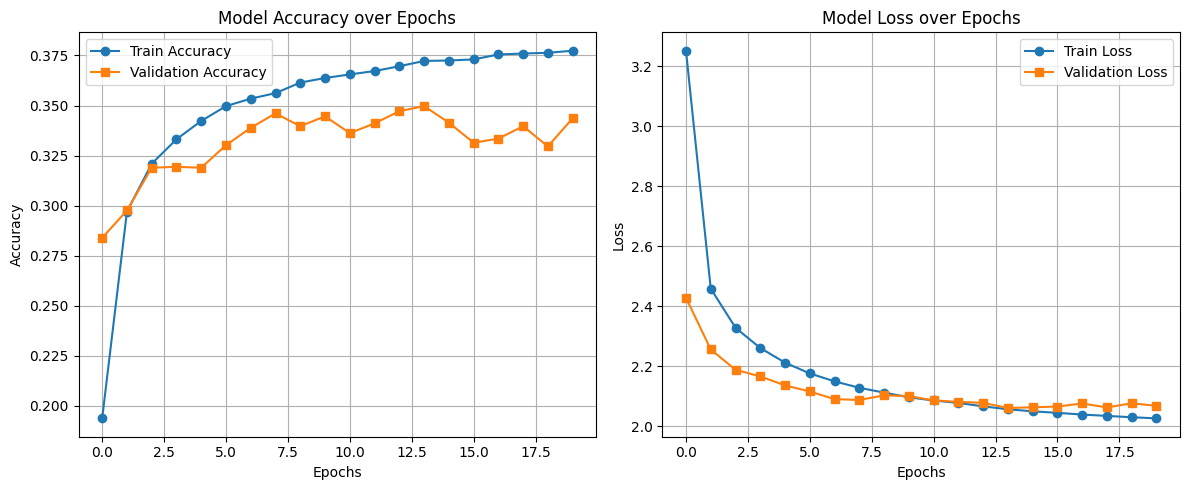

In [10]:
# Load Optuna study
study = optuna.load_study(
    study_name="DNN_diseases_symptoms_dropextremelymore500withSMOTE_study",
    storage="sqlite:///C:/Users/khiew/Downloads/dnn.db"
)

# Get best parameters
best_params = study.best_trial.params

# Rebuild model using best parameters
best_model = keras.Sequential()
best_model.add(layers.Input(shape=(input_dim,)))

for i in range(best_params['n_layers']):
    best_model.add(layers.Dense(best_params[f'n_units_{i}'], activation=best_params[f'activation_{i}']))
    best_model.add(layers.Dropout(best_params[f'dropout_rate_{i}']))

best_model.add(layers.Dense(num_classes, activation='softmax'))

best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fit the model and save training history
history = best_model.fit(
    X_train_resampled,
    y_train_resampled,
    epochs=20,
    batch_size=best_params['batch_size'],
    validation_split=0.2,
    verbose=1
)

# ===========================
# Plotting Training Lifecycle
# ===========================

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import classification_report

y_pred_test = np.argmax(best_model.predict(X_test), axis=1)
print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred_test, target_names=label_encoder.classes_))


1054/1054 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification Report on Test Set:
                                                 precision    recall  f1-score   support

                              actinic keratosis       0.00      0.00      0.00       186
                            acute bronchiolitis       0.41      0.55      0.47       250
                               acute bronchitis       0.95      0.23      0.37       270
                             acute bronchospasm       0.69      0.53      0.60       184
                            acute kidney injury       0.83      0.56      0.67       195
                             acute otitis media       0.21      0.07      0.10       132
                             acute pancreatitis       1.00      0.65      0.79       243
                                acute sinusitis       0.28      0.04      0.07       169
                          acute stress reaction       0.98      0.79      0.87       187
                            adj

c:\Users\khiew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\khiew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\khiew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo